📦 Cell 1: Import Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

📁 Cell 2: Load and Explore the Dataset

In [24]:
# Load with correct separator
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Create total spending (proxy for sales)
df['TotalSpend'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

# Display preview
print(df[['TotalSpend', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].head())
print("\nSummary:")
print(df.describe())

   TotalSpend  NumWebPurchases  NumCatalogPurchases  NumStorePurchases
0        1617                8                   10                  4
1          27                1                    1                  2
2         776                8                    2                 10
3          53                2                    0                  4
4         422                5                    3                  6

Summary:
                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  2240.000000    2216.000000  2240.000000  2240.000000   
mean    5592.159821  1968.805804   52247.251354     0.444196     0.506250   
std     3246.662198    11.984069   25173.076661     0.538398     0.544538   
min        0.000000  1893.000000    1730.000000     0.000000     0.000000   
25%     2828.250000  1959.000000   35303.000000     0.000000     0.000000   
50%     5458.500000  1970.000000   51381.500000     0.000000     0.000000   
75%     8427.750000  1977

📊 Cell 3: Preprocess Features and Target

In [25]:
# Define features and target
features = [
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumDealsPurchases', 'NumWebVisitsMonth'
]
target = 'TotalSpend'

# Drop rows with missing values (if any)
df = df.dropna(subset=features + [target])

# Split the data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale the data for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🧠 Cell 4: Train 3 Models

In [26]:
# Initialize models
lin_reg = LinearRegression()
rf = RandomForestRegressor(random_state=42)
svr = SVR(kernel='rbf', C=100, epsilon=5)

# Train the models
lin_reg.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
svr.fit(X_train_scaled, y_train)

SVR(C=100, epsilon=5)

📈 Cell 5: Evaluate Model Performance

In [27]:
# Predict
lin_preds = lin_reg.predict(X_test_scaled)
rf_preds = rf.predict(X_test)
svr_preds = svr.predict(X_test_scaled)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "R^2 Score": r2}

# Evaluate all models
results = [
    evaluate_model("Linear Regression", y_test, lin_preds),
    evaluate_model("Random Forest", y_test, rf_preds),
    evaluate_model("SVR", y_test, svr_preds),
]

# Print results
results_df = pd.DataFrame(results)
print(results_df)

               Model        RMSE  R^2 Score
0  Linear Regression  318.082837   0.726202
1      Random Forest  272.873938   0.798501
2                SVR  284.096347   0.781586


📉 Cell 6: Visualize Predictions vs Actual

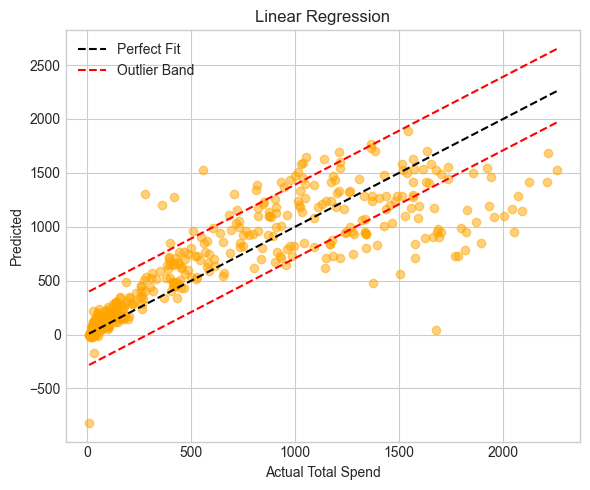

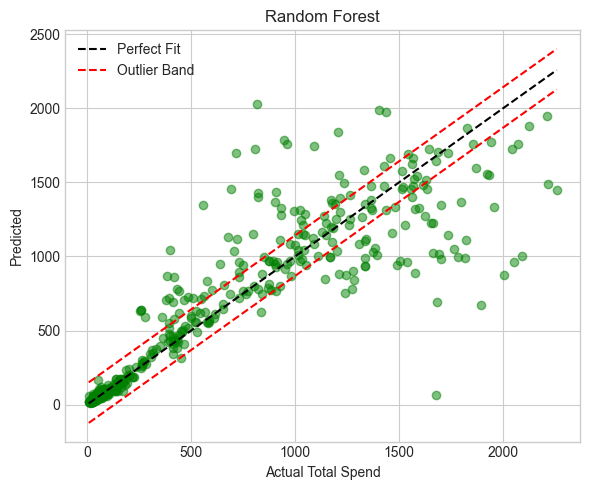

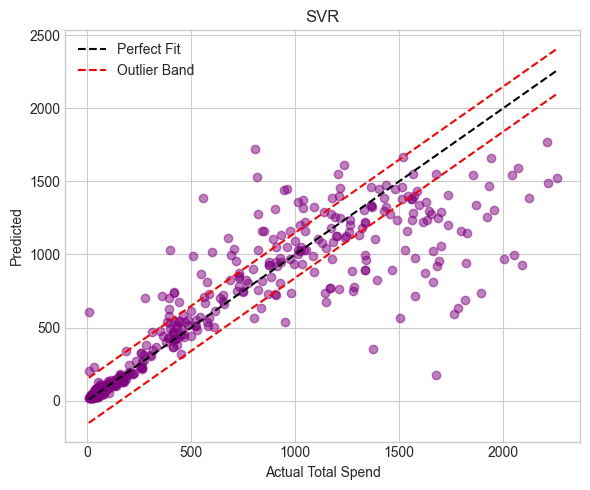

In [28]:
# Helper: diagonal band based on residuals
def get_residual_bounds(y_true, y_pred):
    residuals = y_pred - y_true
    q1 = np.percentile(residuals, 25)
    q3 = np.percentile(residuals, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# Compute bounds
lin_bounds = get_residual_bounds(y_test.values, lin_preds)
rf_bounds = get_residual_bounds(y_test.values, rf_preds)
svr_bounds = get_residual_bounds(y_test.values, svr_preds)

x_vals = np.linspace(y_test.min(), y_test.max(), 100)

# Linear Regression Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, lin_preds, alpha=0.5, color='orange')
plt.plot(x_vals, x_vals, 'k--', label='Perfect Fit')
plt.plot(x_vals, x_vals + lin_bounds[0], 'r--', label='Outlier Band')
plt.plot(x_vals, x_vals + lin_bounds[1], 'r--')
plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Random Forest Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, rf_preds, alpha=0.5, color='green')
plt.plot(x_vals, x_vals, 'k--', label='Perfect Fit')
plt.plot(x_vals, x_vals + rf_bounds[0], 'r--', label='Outlier Band')
plt.plot(x_vals, x_vals + rf_bounds[1], 'r--')
plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# SVR Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, svr_preds, alpha=0.5, color='purple')
plt.plot(x_vals, x_vals, 'k--', label='Perfect Fit')
plt.plot(x_vals, x_vals + svr_bounds[0], 'r--', label='Outlier Band')
plt.plot(x_vals, x_vals + svr_bounds[1], 'r--')
plt.xlabel("Actual Total Spend")
plt.ylabel("Predicted")
plt.title("SVR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

💼 Cell 7: Decision Framework with ROI

In [29]:
# Helper: mean absolute percentage error
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Compute metrics for each model
model_metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "MAE": [
        mean_absolute_error(y_test, lin_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, svr_preds)
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(y_test, lin_preds),
        mean_absolute_percentage_error(y_test, rf_preds),
        mean_absolute_percentage_error(y_test, svr_preds)
    ],
    "Bias": [
        np.mean(lin_preds - y_test),
        np.mean(rf_preds - y_test),
        np.mean(svr_preds - y_test)
    ]
})

print("📊 Model Reliability Metrics:\n")
print(model_metrics.round(2))

# --- CHANNEL-LEVEL DECISION FRAMEWORK ---

# Use the latest test sample
latest_input = X_test.iloc[-1].copy()
actual_sales = y_test.iloc[-1]

# Create +10% spend scenarios
scenarios = []
for channel in features:
    modified = latest_input.copy()
    modified[channel] *= 1.10
    scenarios.append(modified)

scenarios_df = pd.DataFrame(scenarios)
scenarios_scaled = scaler.transform(scenarios_df)

# Predict uplift
lin_preds_10pct = lin_reg.predict(scenarios_scaled)
rf_preds_10pct = rf.predict(scenarios_df)
svr_preds_10pct = svr.predict(scenarios_scaled)

cost_increase = latest_input[features].values * 0.10
lin_uplift = lin_preds_10pct - actual_sales
rf_uplift = rf_preds_10pct - actual_sales
svr_uplift = svr_preds_10pct - actual_sales

lin_roi = lin_uplift / cost_increase
rf_roi = rf_uplift / cost_increase
svr_roi = svr_uplift / cost_increase

# Decision DataFrame
decision_df = pd.DataFrame({
    'Channel': features,
    'Cost Increase ($1k)': cost_increase.round(2),
    'Actual Spend': [actual_sales] * len(features),

    'Linear Predicted Spend': lin_preds_10pct.round(2),
    'Linear Uplift': lin_uplift.round(2),
    'Linear ROI': lin_roi.round(2),

    'RF Predicted Spend': rf_preds_10pct.round(2),
    'RF Uplift': rf_uplift.round(2),
    'RF ROI': rf_roi.round(2),

    'SVR Predicted Spend': svr_preds_10pct.round(2),
    'SVR Uplift': svr_uplift.round(2),
    'SVR ROI': svr_roi.round(2),
})

# Recommendations based on ROI > 1
for model in ['Linear', 'RF', 'SVR']:
    decision_df[f'{model} Recommendation'] = decision_df[f'{model} ROI'].apply(lambda x: '✅ Invest' if x > 1 else '❌ Wait')

print("\n📈 Channel-Level Decision Table:\n")
print(decision_df)

📊 Model Reliability Metrics:

               Model     MAE  MAPE (%)   Bias
0  Linear Regression  206.25     82.45  -5.88
1      Random Forest  143.55     27.76  -8.46
2                SVR  152.29     48.02 -53.09

📈 Channel-Level Decision Table:

               Channel  Cost Increase ($1k)  Actual Spend  \
0      NumWebPurchases                  0.3           172   
1  NumCatalogPurchases                  0.1           172   
2    NumStorePurchases                  0.4           172   
3    NumDealsPurchases                  0.3           172   
4    NumWebVisitsMonth                  0.7           172   

   Linear Predicted Spend  Linear Uplift  Linear ROI  RF Predicted Spend  \
0                  250.33          78.33      261.09              161.85   
1                  246.11          74.11      741.06              161.85   
2                  256.04          84.04      210.11              161.85   
3                  225.56          53.56      178.53              162.70   
4    

C:\Users\User\AppData\Local\Temp\ipykernel_6928\1004140145.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.3000000000000003' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  modified[channel] *= 1.10
C:\Users\User\AppData\Local\Temp\ipykernel_6928\1004140145.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  modified[channel] *= 1.10
C:\Users\User\AppData\Local\Temp\ipykernel_6928\1004140145.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  modified[channel] *= 1.10
C:\Users\User\AppData\Local\Temp\ipykern

📊 Cell 8: Visualize Marginal ROI by Channel for All Models

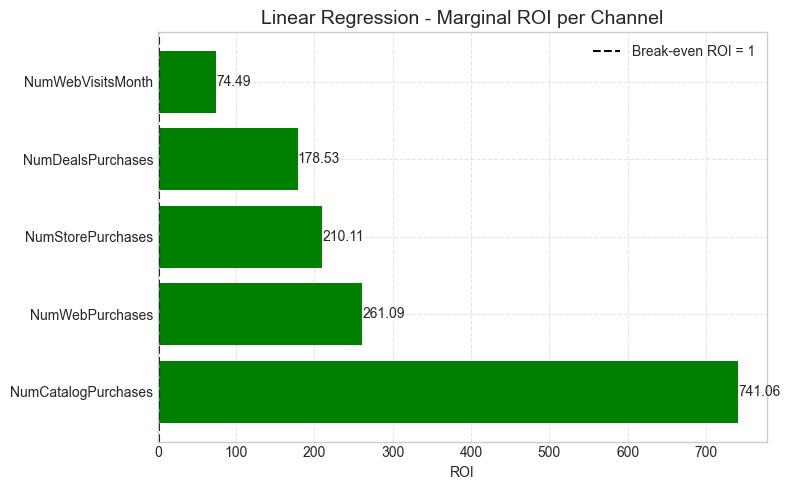

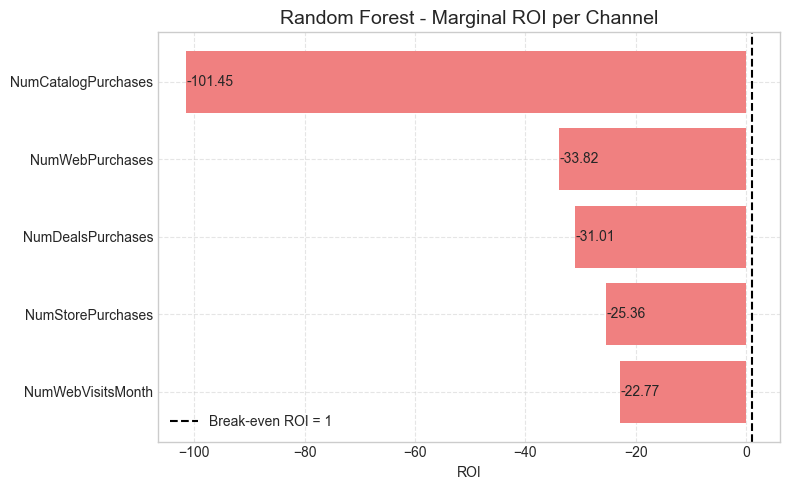

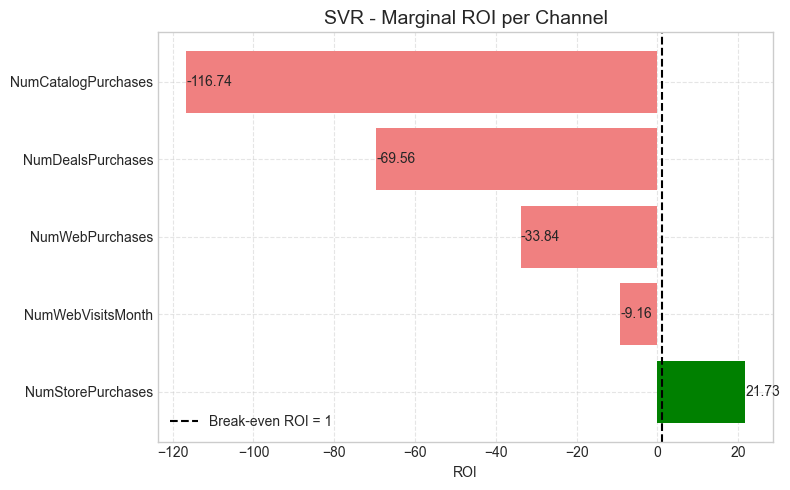

In [30]:
# Helper function to assign colors
def assign_roi_colors(roi_series):
    return ['green' if roi > 1 else 'lightcoral' for roi in roi_series]

# Create separate plots per model with enhancements
for model, roi_col in zip(
    ['Linear Regression', 'Random Forest', 'SVR'],
    ['Linear ROI', 'RF ROI', 'SVR ROI']
):
    plt.figure(figsize=(8, 5))
    
    # Sort channels by ROI
    sorted_df = decision_df.sort_values(by=roi_col, ascending=False)
    colors = assign_roi_colors(sorted_df[roi_col])
    
    bars = plt.barh(
        sorted_df['Channel'],
        sorted_df[roi_col],
        color=colors
    )

    # Annotate bars
    for bar, val in zip(bars, sorted_df[roi_col]):
        plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va='center')

    # Titles and grid
    plt.title(f"{model} - Marginal ROI per Channel", fontsize=14)
    plt.axvline(1, color='black', linestyle='--', label='Break-even ROI = 1')
    plt.xlabel("ROI")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()